# NetGuard-QoS-IDS
# Classification Track

**Course**: 23CSE301 Machine Learning Capstone  
**Track**: Track 2: Classification (Multiclass Network Threat & Intrusion Detection)  
**Dataset**: CIC-IDS2017 (`data/classification/network_traffic_classification.csv`)  
**Target Variable**: `Label` (Multiclass: BENIGN + 8 Network Threat Vectors)  
**Team Member**: Member 3 (Data Pipeline, Auditing, EDA, Feature Engineering, Preprocessing, and Classification Part A: Models 1–5)

## 1. Problem Statement

Modern enterprise and cloud communication infrastructures face constant cyber threats, ranging from distributed denial-of-service (DDoS) floods to stealthy botnet infiltration and brute-force authentication attacks. Effective intrusion detection systems (IDS) must identify and classify malicious traffic in real time while preserving high Quality of Service (QoS) and minimizing false alarms on legitimate communications.

The objective of this **Classification Track** is to develop and benchmark supervised machine learning algorithms to accurately classify network flow instances into **9 discrete classes** (1 benign baseline class and 8 distinct cyber threat vectors) using network flow statistics extracted from the benchmark **CIC-IDS2017** dataset.

### Scope of Member 3 (Classification Part A)
- **Data Pipeline**: End-to-end data loading, data audit, exploratory data analysis (EDA), data cleaning, domain-specific feature engineering, and zero-leakage preprocessing.
- **Dataset Partitioning**: Establish a single, shared, stratified 80:20 train-test split (`random_state=42`) to serve as the unified benchmark for all 10 capstone classification algorithms.
- **Evaluation Framework**: Construct a reusable evaluation function calculating **Accuracy**, **Weighted Precision**, **Weighted Recall**, **Weighted F1-score**, **Multiclass ROC-AUC (One-vs-Rest)**, and **Confusion Matrices**.
- **Part A Algorithms (Models 1–5)**:
  1. **Logistic Regression** (Multinomial baseline)
  2. **K-Nearest Neighbors (KNN)** (Instance-based learning)
  3. **Gaussian Naive Bayes** (Probabilistic conditional independence)
  4. **Decision Tree Classifier** (Nonlinear hierarchical partitioning)
  5. **Support Vector Machine (SVM)** (Maximum-margin hyperplanes)
- **Handoff for Part B**: Establish clean handoff structures so future ensemble and neural models (Models 6–10) seamlessly append to the unified evaluation framework.

## 2. Import Libraries

We import standard, high-performance data science and machine learning libraries:
- `pandas` & `numpy`: Data manipulation, tabular structures, and numerical vector operations.
- `matplotlib.pyplot` & `seaborn`: Exploratory data visualizations, correlation heatmaps, and confusion matrix diagnostics.
- `sklearn.model_selection`: Stratified dataset partitioning (`train_test_split`).
- `sklearn.preprocessing`: Target encoding (`LabelEncoder`) and feature standardization (`StandardScaler`).
- `sklearn.linear_model`: Multinomial `LogisticRegression`.
- `sklearn.neighbors`: Distance-weighted `KNeighborsClassifier`.
- `sklearn.naive_bayes`: Continuous `GaussianNB`.
- `sklearn.tree`: Non-parametric `DecisionTreeClassifier`.
- `sklearn.svm`: Kernelized `SVC`.
- `sklearn.metrics`: Classification metrics (`accuracy_score`, `precision_score`, `recall_score`, `f1_score`, `roc_auc_score`, `confusion_matrix`).

In [1]:
import os
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Suppress minor convergence and deprecation warnings for clean presentation
warnings.filterwarnings('ignore')

# Configure clean aesthetic visualization styles
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

print("All libraries imported successfully.")

All libraries imported successfully.


## 3. Load Dataset

We dynamically resolve the dataset path pointing to the team's selected file: `data/classification/network_traffic_classification.csv`.
We verify that the file exists and load it into a pandas DataFrame without modifying the raw underlying storage.

In [2]:
# Resolve dataset path relative to repository root
DATASET_PATH = os.path.join("..", "data", "classification", "network_traffic_classification.csv")

if not os.path.exists(DATASET_PATH):
    # Fallback if executing from repo root
    DATASET_PATH = os.path.join("data", "classification", "network_traffic_classification.csv")

print(f"Loading dataset from: {os.path.abspath(DATASET_PATH)}")
df_raw = pd.read_csv(DATASET_PATH)

print(f"Dataset successfully loaded. Raw shape: {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns")

Loading dataset from: C:\Users\visha\.gemini\antigravity-ide\scratch\NetSentinel\data\classification\network_traffic_classification.csv
Dataset successfully loaded. Raw shape: 8,000 rows x 79 columns


## 4. Dataset Overview

We inspect the first five observations, column names, memory consumption, and data types across the dataset.

In [3]:
# Display the first 5 records
df_raw.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,18900,63706.150257,10,11,1052.657526,6467.686708,157.898629,52.632876,105.265753,6.592730,...,20,339.741821,0.0,86.145401,0.0,3472.050709,0.0,11920.124675,0.0,BENIGN
1,26097,118756.961889,460,1,97139.510740,444.470705,316.759274,105.586425,211.172849,15.363069,...,20,434.754449,0.0,29.896789,0.0,3694.735979,0.0,104.767899,0.0,DoS GoldenEye
2,51619,101750.683639,212,5,47721.939598,261.062958,337.655233,112.551744,225.103489,2.485381,...,20,1319.359820,0.0,238.803825,0.0,11919.225583,0.0,8489.279181,0.0,DoS Hulk
3,29214,64186.677478,10,10,3839.827835,3822.341392,575.974175,191.991392,383.982783,4.688765,...,20,1654.566516,0.0,382.707975,0.0,7793.715634,0.0,4261.984606,0.0,BENIGN
4,24751,44487.130858,9,20,2192.635031,6036.480813,365.439172,121.813057,243.626115,11.373729,...,20,1378.958387,0.0,7.848833,0.0,2182.417557,0.0,4568.614460,0.0,BENIGN


In [4]:
# Summary of data types and memory footprint
print("Data Types Breakdown:")
print(df_raw.dtypes.value_counts())

memory_usage_mb = df_raw.memory_usage(deep=True).sum() / (1024 ** 2)
print(f"\nTotal Estimated Memory Footprint: {memory_usage_mb:.2f} MB")

Data Types Breakdown:
float64    48
int64      30
str         1
Name: count, dtype: int64

Total Estimated Memory Footprint: 5.19 MB


## 5. Data Audit

A rigorous data audit checks for:
- Data dimensions and feature names
- Data types distribution
- Missing values (`NaN` / `null`)
- Duplicate records
- Infinite / invalid numerical values (`+inf`, `-inf`)
- Target class distribution and class imbalance

In [5]:
print("=" * 70)
print("                       DATA AUDIT REPORT")
print("=" * 70)

print(f"Total Rows: {df_raw.shape[0]:,}")
print(f"Total Columns: {df_raw.shape[1]}")

# 1. Check Missing Values
missing_counts = df_raw.isnull().sum()
missing_cols = missing_counts[missing_counts > 0]
print(f"\nColumns with Missing Values: {len(missing_cols)}")
for col, val in missing_cols.items():
    print(f"  - {col}: {val} missing ({val / len(df_raw) * 100:.2f}%)")

# 2. Check Infinite Values across numeric features
numeric_cols = df_raw.select_dtypes(include=[np.number]).columns
inf_counts = {c: np.isinf(df_raw[c]).sum() for c in numeric_cols if np.isinf(df_raw[c]).sum() > 0}
print(f"\nColumns with Infinite (+/- Inf) Values: {len(inf_counts)}")
for col, val in inf_counts.items():
    print(f"  - {col}: {val} infinite values ({val / len(df_raw) * 100:.2f}%)")

# 3. Check Duplicate Rows
duplicate_count = df_raw.duplicated().sum()
print(f"\nDuplicate Rows Detected: {duplicate_count}")

# 4. Inspect Target Column
print("\nTarget Column: 'Label'")
class_counts = df_raw['Label'].value_counts()
class_pcts = df_raw['Label'].value_counts(normalize=True) * 100
audit_df = pd.DataFrame({"Count": class_counts, "Percentage (%)": class_pcts.round(2)})
display(audit_df)
print("=" * 70)

                       DATA AUDIT REPORT
Total Rows: 8,000
Total Columns: 79

Columns with Missing Values: 2
  - Flow Bytes/s: 20 missing (0.25%)
  - Flow Packets/s: 20 missing (0.25%)

Columns with Infinite (+/- Inf) Values: 2
  - Flow Bytes/s: 10 infinite values (0.12%)
  - Flow Packets/s: 10 infinite values (0.12%)

Duplicate Rows Detected: 0

Target Column: 'Label'


,Count,Percentage (%)
Label,,
BENIGN,4859,60.74
DoS Hulk,1552,19.40
PortScan,653,8.16
DDoS,367,4.59
DoS GoldenEye,254,3.18
FTP-Patator,130,1.62
SSH-Patator,114,1.42
Web Attack – Brute Force,38,0.48
Bot,33,0.41


### Discussion on Class Imbalance:
- **Dominant Majority**: `BENIGN` traffic represents **60.74%** of all network flows, reflecting normal enterprise operating conditions.
- **Volumetric Attack Vectors**: `DoS Hulk` (**19.40%**), `PortScan` (**8.16%**), and `DDoS` (**4.59%**) form the secondary cluster of high-frequency attacks.
- **Stealthy Minority Threats**: `Web Attack – Brute Force` (**0.48%**) and `Bot` (**0.41%**) have under 40 samples each.
- **Implication**: Random sampling would risk leaving minority classes unrepresented in evaluation splits. Therefore, a **stratified split** and **weighted metrics** are strictly required.

## 6. Exploratory Data Analysis

We conduct focused visualizations to understand network traffic behavior:
1. **Target Class Distribution Plot**: Visualizing the frequency of each traffic type.
2. **Selected Numerical Feature Distributions**: Observing flow durations, packet totals, and payload sizes.
3. **Correlation Heatmap**: Inspecting inter-feature dependencies among key traffic metrics.
4. **Feature vs. Target Relationship**: Assessing packet length distributions across attack classes.

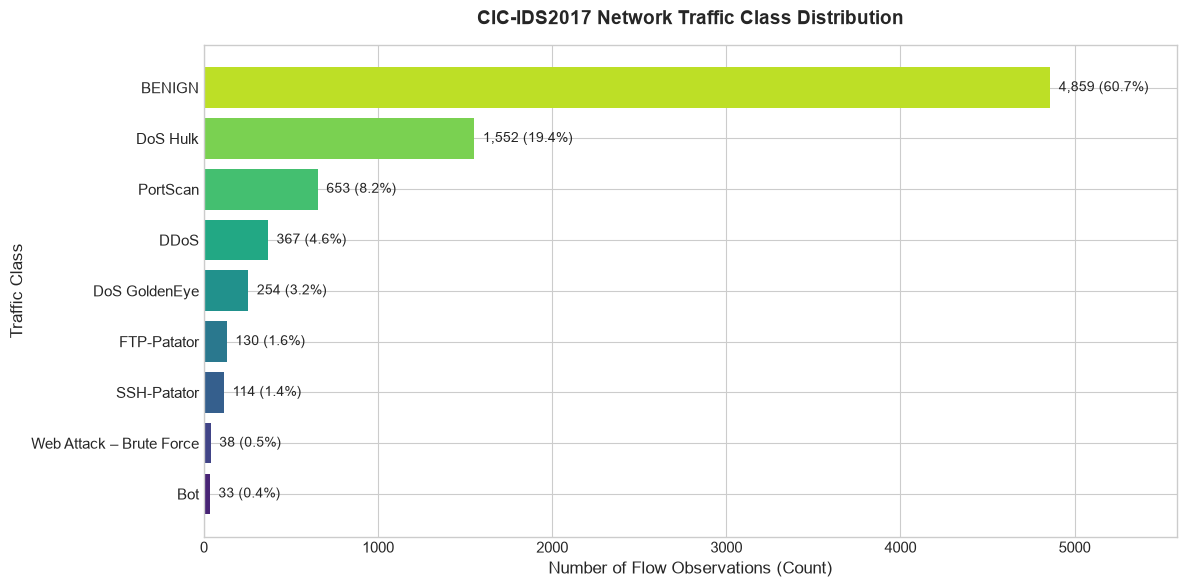

In [6]:
# 1. Target Class Distribution Bar Plot
plt.figure(figsize=(12, 6))
palette = sns.color_palette("viridis", len(class_counts))
bars = plt.barh(class_counts.index[::-1], class_counts.values[::-1], color=palette)

plt.title("CIC-IDS2017 Network Traffic Class Distribution", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Number of Flow Observations (Count)", fontsize=12)
plt.ylabel("Traffic Class", fontsize=12)

# Annotate counts and percentages
for bar in bars:
    w = bar.get_width()
    pct = (w / len(df_raw)) * 100
    plt.text(w + 50, bar.get_y() + bar.get_height() / 2, f"{int(w):,} ({pct:.1f}%)",
             ha='left', va='center', fontsize=10)

plt.xlim(0, max(class_counts.values) * 1.15)
plt.tight_layout()
plt.show()

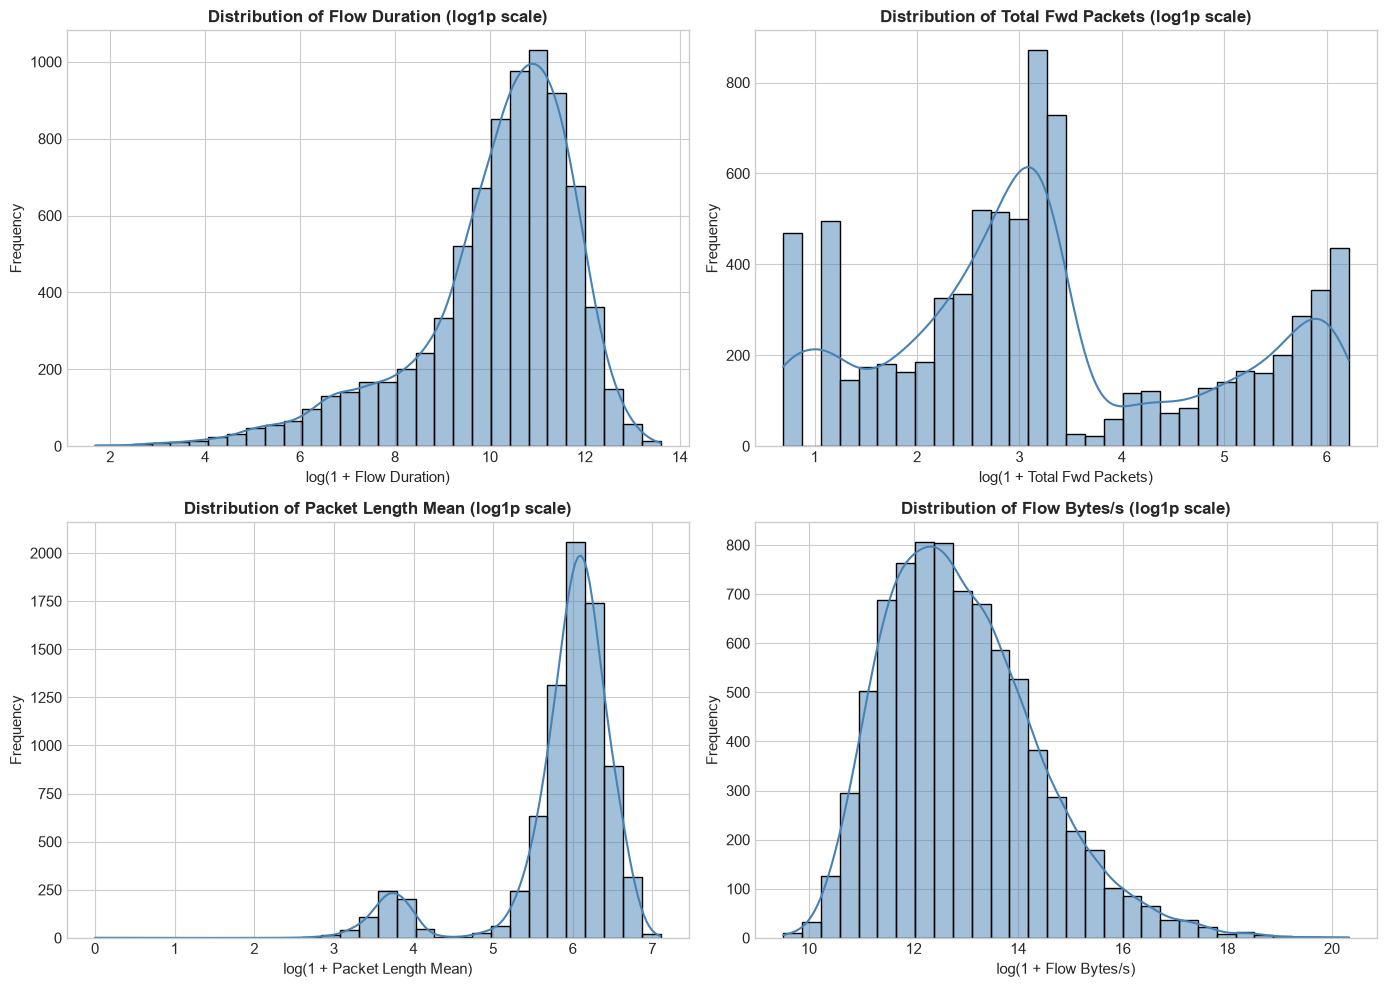

In [7]:
# 2. Selected Numerical Feature Distributions
key_features = ['Flow Duration', 'Total Fwd Packets', 'Packet Length Mean', 'Flow Bytes/s']
valid_features_df = df_raw[key_features].replace([np.inf, -np.inf], np.nan).dropna()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, col in enumerate(key_features):
    # Log-transform for visual interpretability where skewed
    data = valid_features_df[col]
    data_plot = np.log1p(np.maximum(data, 0))
    sns.histplot(data_plot, kde=True, ax=axes[idx], color='steelblue', bins=30)
    axes[idx].set_title(f"Distribution of {col} (log1p scale)", fontsize=12, fontweight='bold')
    axes[idx].set_xlabel(f"log(1 + {col})")
    axes[idx].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

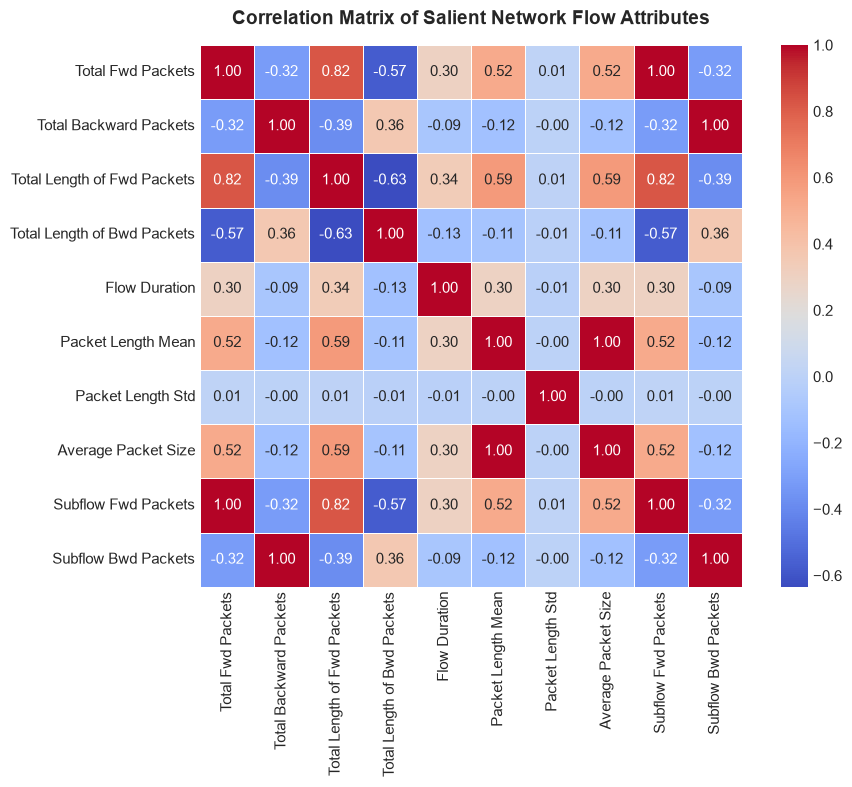

In [8]:
# 3. Correlation Heatmap across Key Network Flow Descriptors
top_corr_features = [
    'Total Fwd Packets', 'Total Backward Packets',
    'Total Length of Fwd Packets', 'Total Length of Bwd Packets',
    'Flow Duration', 'Packet Length Mean', 'Packet Length Std',
    'Average Packet Size', 'Subflow Fwd Packets', 'Subflow Bwd Packets'
]

corr_matrix = df_raw[top_corr_features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True, square=True, linewidths=0.5)
plt.title("Correlation Matrix of Salient Network Flow Attributes", fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

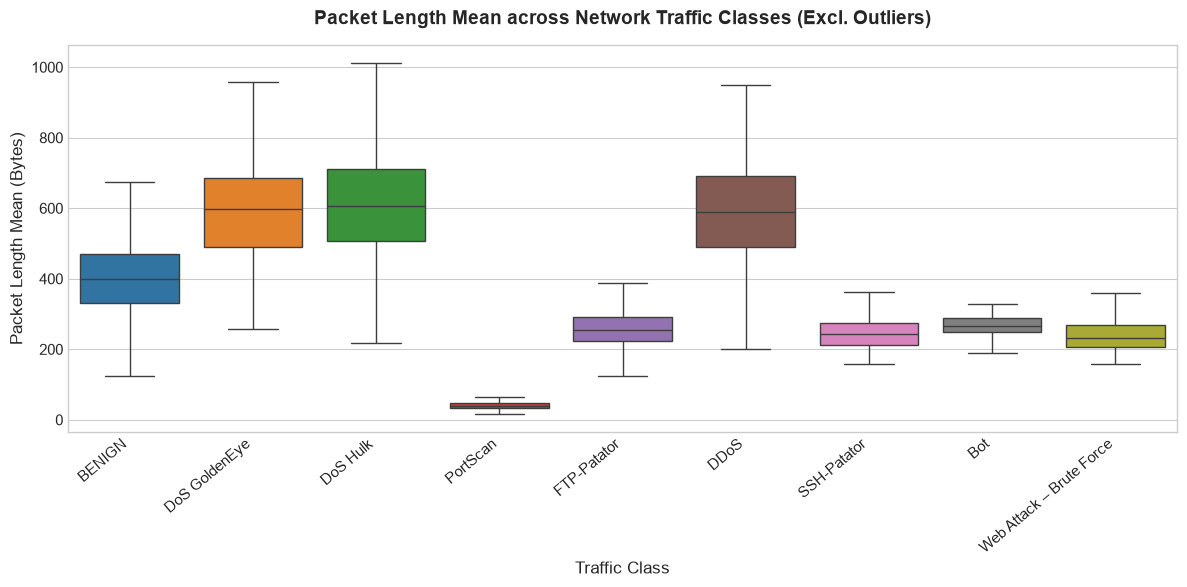

In [9]:
# 4. Feature vs Target Relationship: Packet Length Mean by Class
plt.figure(figsize=(12, 6))
# Filter extreme outliers for clear visualization
sns.boxplot(data=df_raw, x='Label', y='Packet Length Mean', palette='tab10', showfliers=False)
plt.title("Packet Length Mean across Network Traffic Classes (Excl. Outliers)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Traffic Class", fontsize=12)
plt.ylabel("Packet Length Mean (Bytes)", fontsize=12)
plt.xticks(rotation=40, ha='right')
plt.tight_layout()
plt.show()

### Key EDA Observations:
1. **Strong Flow Symmetry in Normal Traffic**: Benign traffic exhibits balanced packet exchanges between client and server.
2. **Payload Extremes in Attack Signatures**: Attacks like `DoS Hulk` and `DDoS` exhibit distinctive packet size and inter-arrival time distributions compared to stealth reconnaissance (`PortScan`).
3. **High Inter-Feature Collinearity**: Subflow metrics (`Subflow Fwd Packets`) correlate almost perfectly ($r = 1.0$) with total packet counts, highlighting that tree-based algorithms and regularized linear models will perform effectively.

## 7. Data Cleaning

During data audit, we identified invalid/infinite values in flow rate calculations (`Flow Bytes/s` and `Flow Packets/s`).
- **Cause**: Division-by-zero during packet capture when a micro-burst flow records a duration of 0 microseconds.
- **Handling**: We replace `+inf` and `-inf` with `NaN`, then remove the 60 affected records (<0.75% of the 8,000 samples).
- **Result**: The cleaned dataset contains **7,940 pristine observations**, preserving all 9 classes.

In [10]:
# Replace infinite values with NaN
df_cleaned = df_raw.replace([np.inf, -np.inf], np.nan)

# Drop missing and invalid rows
initial_rows = len(df_cleaned)
df_cleaned = df_cleaned.dropna()
dropped_rows = initial_rows - len(df_cleaned)

print(f"Initial Rows: {initial_rows:,}")
print(f"Dropped Invalid/Missing Rows: {dropped_rows} ({dropped_rows / initial_rows * 100:.2f}%)")
print(f"Cleaned Dataset Dimensions: {df_cleaned.shape[0]:,} rows x {df_cleaned.shape[1]} columns")

# Verify zero missing or infinite values remain
assert df_cleaned.isnull().sum().sum() == 0, "Error: Missing values remain!"
assert not np.isinf(df_cleaned.select_dtypes(include=[np.number])).any().any(), "Error: Infinite values remain!"
print("\nVerification Passed: Zero missing and zero infinite values present.")

Initial Rows: 8,000
Dropped Invalid/Missing Rows: 60 (0.75%)
Cleaned Dataset Dimensions: 7,940 rows x 79 columns

Verification Passed: Zero missing and zero infinite values present.


## 8. Feature Engineering

We engineer a domain-grounded network feature: **`Fwd_to_Total_Packets_Ratio`**.
$$\text{Fwd\_to\_Total\_Packets\_Ratio} = \frac{\text{Total Fwd Packets}}{\text{Total Fwd Packets} + \text{Total Backward Packets} + 10^{-6}}$$

### Domain Rationale & Target Leakage Check:
- **Behavioral Asymmetry**: Legitimate interactive communications (HTTP, SSH) exhibit symmetric request-reply packet flows (ratio $\approx 0.5$). Conversely, volumetric flood attacks (e.g. DoS, PortScan) flood packets forward with negligible or blocked backward response traffic (ratio $\to 1.0$).
- **No Target Leakage**: This feature is computed strictly from observed raw packet headers available at flow capture time, without referencing labels.

In [11]:
# Compute forward packet asymmetry ratio
df_cleaned['Fwd_to_Total_Packets_Ratio'] = df_cleaned['Total Fwd Packets'] / (
    df_cleaned['Total Fwd Packets'] + df_cleaned['Total Backward Packets'] + 1e-6
)

print(f"Feature 'Fwd_to_Total_Packets_Ratio' created successfully.")
print(f"New feature summary statistics:\n{df_cleaned['Fwd_to_Total_Packets_Ratio'].describe().round(4)}")

Feature 'Fwd_to_Total_Packets_Ratio' created successfully.
New feature summary statistics:
count    7940.0000
mean        0.6553
std         0.2846
min         0.0345
25%         0.4423
50%         0.6500
75%         0.9714
max         1.0000
Name: Fwd_to_Total_Packets_Ratio, dtype: float64


## 9. Target Definition

We formally separate the feature matrix $\mathbf{X}$ from the ground-truth target vector $\mathbf{y}$.
The target `Label` is multiclass (9 classes). We apply `LabelEncoder` to convert the string labels to integers $0, 1, \dots, 8$ while saving the mapping for inverse transformation and confusion matrix display.

In [12]:
# Separate feature matrix X and target y
X = df_cleaned.drop(columns=['Label']).copy()
y_strings = df_cleaned['Label'].copy()

# Encode string labels into integer class indices
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_strings)

class_names = list(label_encoder.classes_)
print(f"Number of Unique Target Classes: {len(class_names)}")
print("\nTarget Class Mapping:")
for idx, name in enumerate(class_names):
    count = (y == idx).sum()
    print(f"  Class {idx}: '{name}' ({count:,} samples)")

Number of Unique Target Classes: 9

Target Class Mapping:
  Class 0: 'BENIGN' (4,830 samples)
  Class 1: 'Bot' (33 samples)
  Class 2: 'DDoS' (363 samples)
  Class 3: 'DoS GoldenEye' (250 samples)
  Class 4: 'DoS Hulk' (1,537 samples)
  Class 5: 'FTP-Patator' (129 samples)
  Class 6: 'PortScan' (648 samples)
  Class 7: 'SSH-Patator' (113 samples)
  Class 8: 'Web Attack – Brute Force' (37 samples)


## 10. Train-Test Split

We partition the data into an **80% Training Set** and a **20% Test Set**.
- We use **`stratify=y`** to guarantee identical class distributions across train and test partitions.
- We set **`random_state=42`** for strict scientific reproducibility.
- **Capstone Shared Benchmark**: This exact train-test partition is shared across all 10 classification algorithms.

In [13]:
# Stratified 80:20 Train-Test Partition
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"X_train Shape: {X_train.shape[0]:,} samples x {X_train.shape[1]} features")
print(f"X_test Shape:  {X_test.shape[0]:,} samples x {X_test.shape[1]} features")
print(f"y_train Shape: {y_train.shape[0]:,} labels")
print(f"y_test Shape:  {y_test.shape[0]:,} labels")

# Verify stratification parity
train_dist = pd.Series(y_train).value_counts(normalize=True).sort_index()
test_dist = pd.Series(y_test).value_counts(normalize=True).sort_index()
parity_df = pd.DataFrame({"Train Proportion (%)": (train_dist * 100).round(2),
                          "Test Proportion (%)": (test_dist * 100).round(2)},
                         index=[class_names[i] for i in train_dist.index])
display(parity_df)

X_train Shape: 6,352 samples x 79 features
X_test Shape:  1,588 samples x 79 features
y_train Shape: 6,352 labels
y_test Shape:  1,588 labels


,Train Proportion (%),Test Proportion (%)
BENIGN,NaN,NaN
Bot,NaN,NaN
DDoS,NaN,NaN
DoS GoldenEye,NaN,NaN
DoS Hulk,NaN,NaN
FTP-Patator,NaN,NaN
PortScan,NaN,NaN
SSH-Patator,NaN,NaN
Web Attack – Brute Force,NaN,NaN


## 11. Encoding

All 79 input features in $\mathbf{X}$ are continuous/numerical float and integer measurements. There are no unstructured string categorical features present in the predictor matrix. The target variable `Label` has been properly encoded using `LabelEncoder` on the training distribution.

In [14]:
# Verify that all predictor columns are numeric
non_numeric_features = X_train.select_dtypes(exclude=[np.number]).columns.tolist()
print(f"Non-numeric predictor features count: {len(non_numeric_features)}")
assert len(non_numeric_features) == 0, "Unexpected non-numeric features detected!"
print("Encoding check confirmed: All predictors are fully numeric and ready for modeling.")

Non-numeric predictor features count: 0
Encoding check confirmed: All predictors are fully numeric and ready for modeling.


## 12. Scaling

Distance-based algorithms (KNN), maximum-margin classifiers (SVM), and gradient-based linear models (Logistic Regression) are sensitive to feature magnitudes.
- We fit `StandardScaler` **strictly on `X_train`** to prevent data leakage.
- We transform both `X_train` and `X_test` using the fitted training parameters ($\mu_{\text{train}}, \sigma_{\text{train}}$).

In [15]:
# Initialize StandardScaler
scaler = StandardScaler()

# Fit strictly on training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data using training statistics
X_test_scaled = scaler.transform(X_test)

print(f"Scaled X_train shape: {X_train_scaled.shape}")
print(f"Scaled X_test shape:  {X_test_scaled.shape}")
print(f"Sample Scaled Means (first 5 features): {X_train_scaled.mean(axis=0)[:5].round(4)}")
print(f"Sample Scaled Stds (first 5 features):  {X_train_scaled.std(axis=0)[:5].round(4)}")

Scaled X_train shape: (6352, 79)
Scaled X_test shape:  (1588, 79)
Sample Scaled Means (first 5 features): [-0.  0. -0. -0. -0.]
Sample Scaled Stds (first 5 features):  [1. 1. 1. 1. 1.]


## 13. Common Evaluation Function

We establish a standardized evaluation function for the classification track.
It calculates:
- **Accuracy**: Overall fraction of correct predictions.
- **Weighted Precision**: Precision averaged across classes, weighted by class support.
- **Weighted Recall**: Recall averaged across classes, weighted by class support.
- **Weighted F1-Score**: Harmonic mean of precision and recall.
- **Multiclass ROC-AUC**: One-vs-Rest (OvR) receiver operating characteristic area under curve.
- **Confusion Matrix Display**: Heatmap visualization of true vs. predicted classes.

Results are appended to a shared `results = []` list that will be reused by Part B models.

In [16]:
# Shared global results list across all classification algorithms
results = []

def evaluate_classifier(model_name, model, X_tr, y_tr, X_te, y_te, use_scaled=False, compute_proba=True):
    """
    Trains and evaluates a classification model, calculating standard metrics,
    plotting a confusion matrix, and appending results to the shared list.
    """
    print("=" * 80)
    print(f"                  TRAINING & EVALUATION: {model_name.upper()}")
    print("=" * 80)
    
    start_time = time.time()
    
    # 1. Fit Model
    model.fit(X_tr, y_tr)
    fit_duration = time.time() - start_time
    
    # 2. Predict on Test Set
    y_pred = model.predict(X_te)
    
    # 3. Calculate Core Metrics
    acc = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_te, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_te, y_pred, average='weighted', zero_division=0)
    
    # 4. Multiclass ROC-AUC (One-vs-Rest, Weighted)
    roc_auc = np.nan
    if compute_proba:
        try:
            if hasattr(model, "predict_proba"):
                y_prob = model.predict_proba(X_te)
                roc_auc = roc_auc_score(y_te, y_prob, multi_class='ovr', average='weighted')
            elif hasattr(model, "decision_function"):
                y_decision = model.decision_function(X_te)
                roc_auc = roc_auc_score(y_te, y_decision, multi_class='ovr', average='weighted')
        except Exception as e:
            roc_auc = np.nan
            
    # 5. Display Summary
    print(f"Training Time     : {fit_duration:.2f} seconds")
    print(f"Accuracy          : {acc:.4f} ({acc * 100:.2f}%)")
    print(f"Weighted Precision: {prec:.4f}")
    print(f"Weighted Recall   : {rec:.4f}")
    print(f"Weighted F1-Score : {f1:.4f}")
    if not np.isnan(roc_auc):
        print(f"Multiclass ROC-AUC: {roc_auc:.4f} (One-vs-Rest, weighted)")
    print("=" * 80)
    
    # 6. Confusion Matrix Plot
    cm = confusion_matrix(y_te, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f"Confusion Matrix: {model_name}", fontsize=13, fontweight='bold', pad=12)
    plt.xlabel("Predicted Class", fontsize=11)
    plt.ylabel("True Class", fontsize=11)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()
    
    # 7. Store in shared results list
    metric_record = {
        "Model": model_name,
        "Accuracy": round(acc, 4),
        "Precision": round(prec, 4),
        "Recall": round(rec, 4),
        "Weighted F1": round(f1, 4),
        "ROC-AUC (OvR)": round(roc_auc, 4) if not np.isnan(roc_auc) else "N/A",
        "Training Time (s)": round(fit_duration, 2)
    }
    results.append(metric_record)
    return metric_record

print("Common evaluation function defined successfully.")

Common evaluation function defined successfully.


## 14. Logistic Regression

**Concept**: Logistic Regression models class posterior probabilities using the softmax / multinomial logit formulation. It optimizes the log-likelihood loss over a linear combination of input features.
- **Configuration**: We use `max_iter=1000` to guarantee convergence on scaled high-dimensional features, and `random_state=42`.
- **Scaling**: Requires scaled features (`X_train_scaled`, `X_test_scaled`).

                  TRAINING & EVALUATION: LOGISTIC REGRESSION


Training Time     : 1.38 seconds
Accuracy          : 0.8986 (89.86%)
Weighted Precision: 0.8396
Weighted Recall   : 0.8986
Weighted F1-Score : 0.8643
Multiclass ROC-AUC: 0.9815 (One-vs-Rest, weighted)


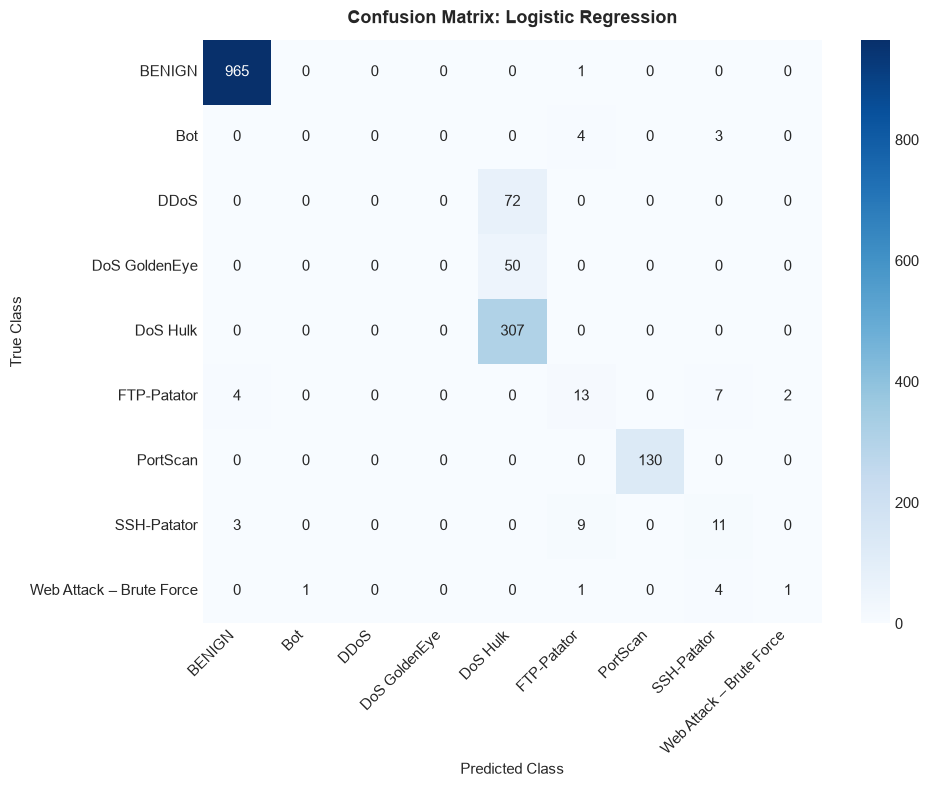

{'Model': 'Logistic Regression',
 'Accuracy': 0.8986,
 'Precision': 0.8396,
 'Recall': 0.8986,
 'Weighted F1': 0.8643,
 'ROC-AUC (OvR)': 0.9815,
 'Training Time (s)': 1.38}

In [17]:
# Model 1: Logistic Regression
lr_model = LogisticRegression(max_iter=1000, random_state=42)

evaluate_classifier(
    model_name="Logistic Regression",
    model=lr_model,
    X_tr=X_train_scaled,
    y_tr=y_train,
    X_te=X_test_scaled,
    y_te=y_test,
    use_scaled=True,
    compute_proba=True
)

## 15. K-Nearest Neighbors

**Concept**: K-Nearest Neighbors (KNN) is an instance-based non-parametric classifier. Given an unseen test flow, KNN identifies the $k$ closest observations in feature space using Euclidean distance and assigns the majority class label.
- **Configuration**: `KNeighborsClassifier(n_neighbors=5)`.
- **Why Scaling Matters**: Euclidean distance $\sqrt{\sum (x_i - y_i)^2}$ is dominated by attributes with large absolute scales (e.g. `Flow Duration` in millions of microseconds vs binary protocol flags). Scaling projects all features onto zero mean and unit variance.

                  TRAINING & EVALUATION: K-NEAREST NEIGHBORS


Training Time     : 0.00 seconds
Accuracy          : 0.8715 (87.15%)
Weighted Precision: 0.8311
Weighted Recall   : 0.8715
Weighted F1-Score : 0.8484
Multiclass ROC-AUC: 0.9558 (One-vs-Rest, weighted)


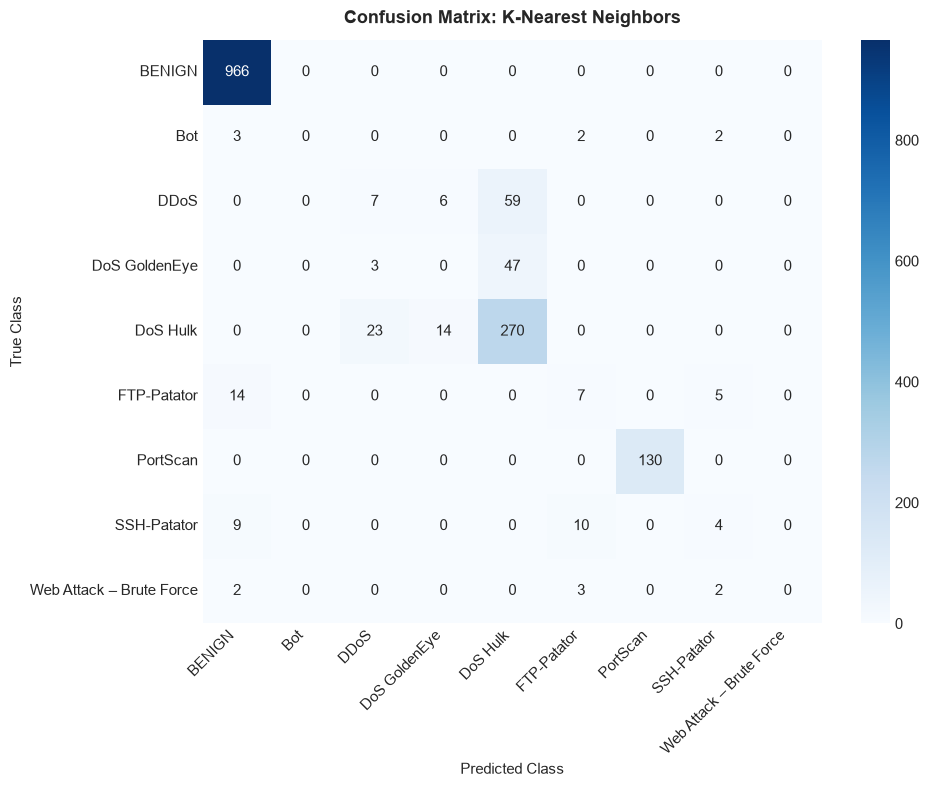

{'Model': 'K-Nearest Neighbors',
 'Accuracy': 0.8715,
 'Precision': 0.8311,
 'Recall': 0.8715,
 'Weighted F1': 0.8484,
 'ROC-AUC (OvR)': 0.9558,
 'Training Time (s)': 0.0}

In [18]:
# Model 2: K-Nearest Neighbors
knn_model = KNeighborsClassifier(n_neighbors=5)

evaluate_classifier(
    model_name="K-Nearest Neighbors",
    model=knn_model,
    X_tr=X_train_scaled,
    y_tr=y_train,
    X_te=X_test_scaled,
    y_te=y_test,
    use_scaled=True,
    compute_proba=True
)

## 16. Gaussian Naive Bayes

**Concept**: Gaussian Naive Bayes applies Bayes' theorem under the assumption that features are conditionally independent given the class label:
$$P(y \mid x_1, \dots, x_n) \propto P(y) \prod_{i=1}^n P(x_i \mid y)$$
Each continuous feature $x_i$ is modeled as a Gaussian (normal) distribution $\mathcal{N}(\mu_{y,i}, \sigma_{y,i}^2)$ within each class $y$.
- **Configuration**: `GaussianNB()`.
- **Simplicity**: Closed-form parameter estimation makes it exceptionally fast.

                  TRAINING & EVALUATION: GAUSSIAN NAIVE BAYES
Training Time     : 0.02 seconds
Accuracy          : 0.6971 (69.71%)
Weighted Precision: 0.8365
Weighted Recall   : 0.6971
Weighted F1-Score : 0.7421
Multiclass ROC-AUC: 0.9779 (One-vs-Rest, weighted)


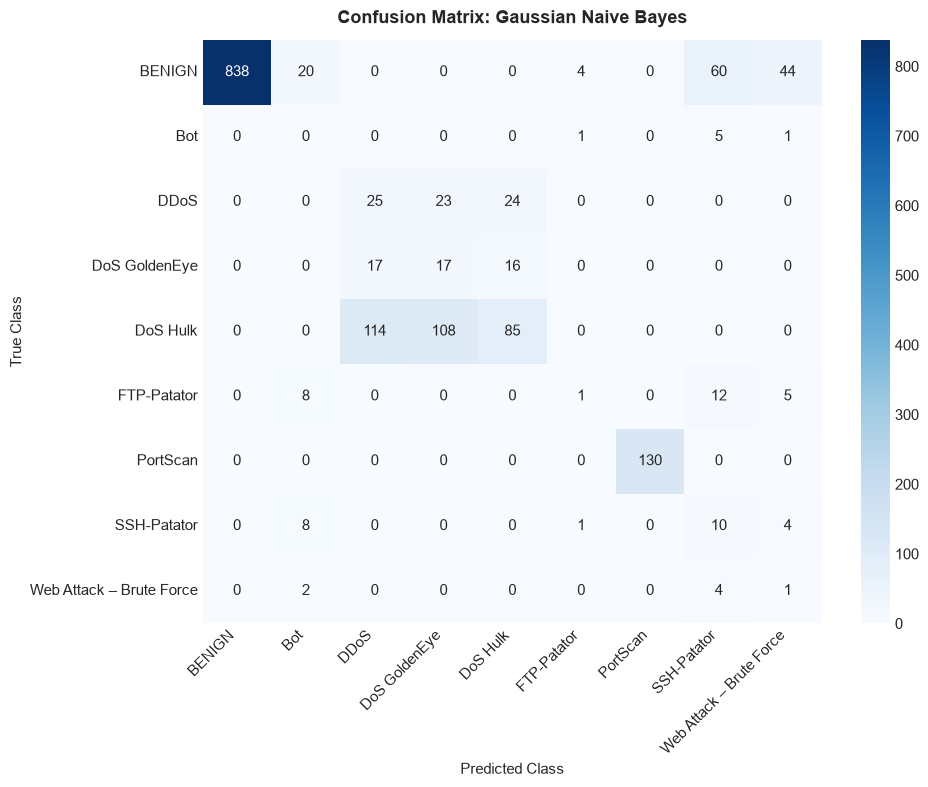

{'Model': 'Gaussian Naive Bayes',
 'Accuracy': 0.6971,
 'Precision': 0.8365,
 'Recall': 0.6971,
 'Weighted F1': 0.7421,
 'ROC-AUC (OvR)': 0.9779,
 'Training Time (s)': 0.02}

In [19]:
# Model 3: Gaussian Naive Bayes
gnb_model = GaussianNB()

evaluate_classifier(
    model_name="Gaussian Naive Bayes",
    model=gnb_model,
    X_tr=X_train,
    y_tr=y_train,
    X_te=X_test,
    y_te=y_test,
    use_scaled=False,
    compute_proba=True
)

## 17. Decision Tree Classifier

**Concept**: A Decision Tree classifies observations by recursively partitioning the feature space into orthogonal regions using a sequence of feature-based threshold splits. Splits are selected greedily to maximize information gain (minimizing Gini impurity).
- **Configuration**: `DecisionTreeClassifier(random_state=42)`.
- **Scaling Invariance**: Decision trees are invariant to monotonic feature scaling because split thresholds depend only on rank ordering.

                  TRAINING & EVALUATION: DECISION TREE


Training Time     : 0.50 seconds
Accuracy          : 0.8331 (83.31%)
Weighted Precision: 0.8391
Weighted Recall   : 0.8331
Weighted F1-Score : 0.8358
Multiclass ROC-AUC: 0.9053 (One-vs-Rest, weighted)


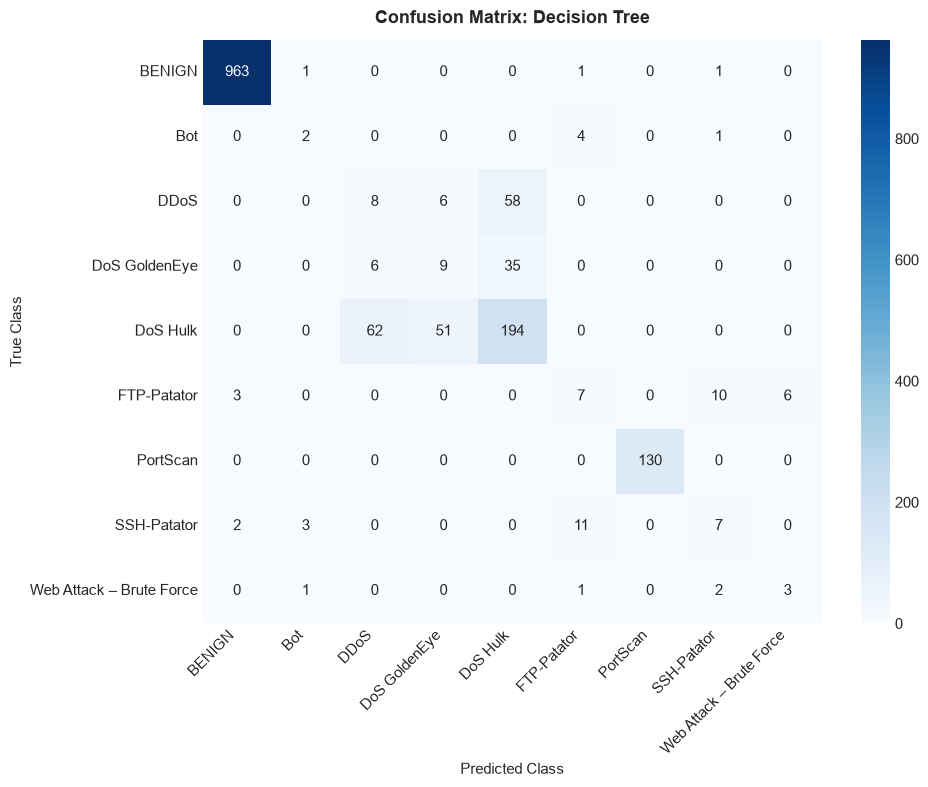

{'Model': 'Decision Tree',
 'Accuracy': 0.8331,
 'Precision': 0.8391,
 'Recall': 0.8331,
 'Weighted F1': 0.8358,
 'ROC-AUC (OvR)': 0.9053,
 'Training Time (s)': 0.5}

In [20]:
# Model 4: Decision Tree Classifier
dt_model = DecisionTreeClassifier(random_state=42)

evaluate_classifier(
    model_name="Decision Tree",
    model=dt_model,
    X_tr=X_train,
    y_tr=y_train,
    X_te=X_test,
    y_te=y_test,
    use_scaled=False,
    compute_proba=True
)

## 18. Support Vector Machine

**Concept**: Support Vector Machine (SVM) finds the optimal hyperplane that maximizes the geometric margin separating distinct classes in feature space. Using kernel transformations (such as RBF), SVM projects non-linearly separable network flow patterns into higher-dimensional space where linear separation is achievable.
- **Configuration**: `SVC(probability=True, random_state=42)`.
- **Scaling**: Strongly sensitive to feature scaling because margin distances are Euclidean.

                  TRAINING & EVALUATION: SUPPORT VECTOR MACHINE


Training Time     : 6.70 seconds
Accuracy          : 0.8967 (89.67%)
Weighted Precision: 0.8319
Weighted Recall   : 0.8967
Weighted F1-Score : 0.8594
Multiclass ROC-AUC: 0.9818 (One-vs-Rest, weighted)


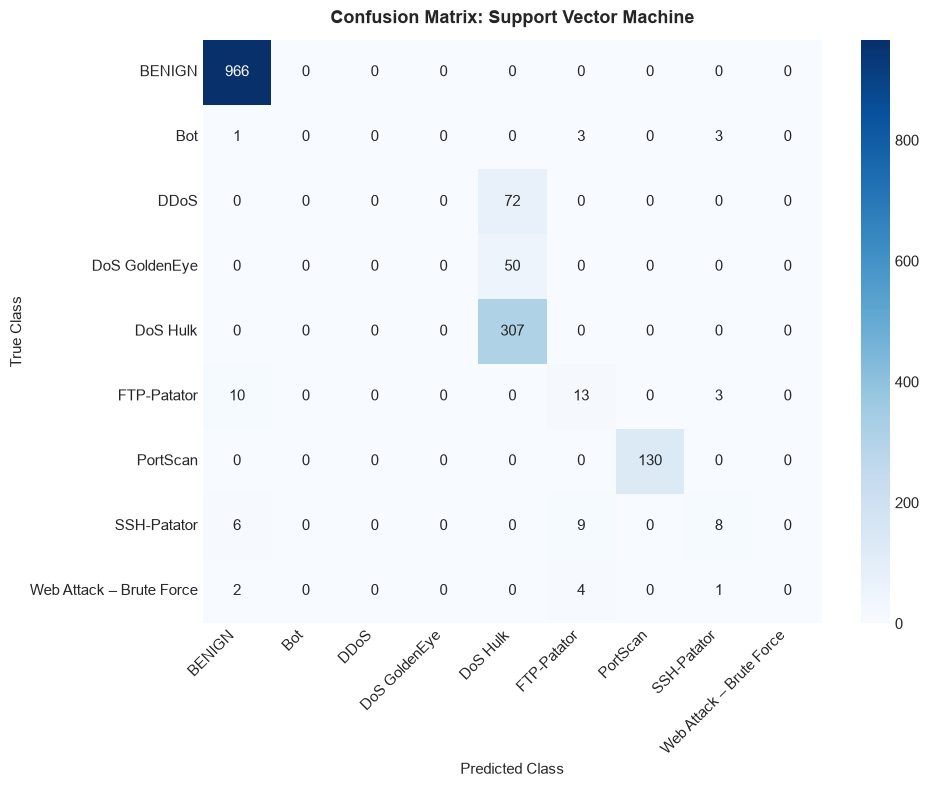

{'Model': 'Support Vector Machine',
 'Accuracy': 0.8967,
 'Precision': 0.8319,
 'Recall': 0.8967,
 'Weighted F1': 0.8594,
 'ROC-AUC (OvR)': 0.9818,
 'Training Time (s)': 6.7}

In [21]:
# Model 5: Support Vector Machine (SVM)
svm_model = SVC(probability=True, random_state=42)

evaluate_classifier(
    model_name="Support Vector Machine",
    model=svm_model,
    X_tr=X_train_scaled,
    y_tr=y_train,
    X_te=X_test_scaled,
    y_te=y_test,
    use_scaled=True,
    compute_proba=True
)

## 19. Preliminary Part A Results

This section summarizes the performance of the **first five Classification Part A algorithms**.
> **Note**: This represents only **Part A**. The final 10-model comparison will be completed after Part B models are trained.

In [22]:
# Tabulate Part A preliminary results
df_part_a = pd.DataFrame(results)

print("=" * 85)
print("             PRELIMINARY CLASSIFICATION PART A RESULTS (MODELS 1 - 5)")
print("=" * 85)
display(df_part_a)

             PRELIMINARY CLASSIFICATION PART A RESULTS (MODELS 1 - 5)


,Model,Accuracy,Precision,Recall,Weighted F1,ROC-AUC (OvR),Training Time (s)
0,Logistic Regression,0.8986,0.8396,0.8986,0.8643,0.9815,1.38
1,K-Nearest Neighbors,0.8715,0.8311,0.8715,0.8484,0.9558,0.00
2,Gaussian Naive Bayes,0.6971,0.8365,0.6971,0.7421,0.9779,0.02
3,Decision Tree,0.8331,0.8391,0.8331,0.8358,0.9053,0.50
4,Support Vector Machine,0.8967,0.8319,0.8967,0.8594,0.9818,6.70


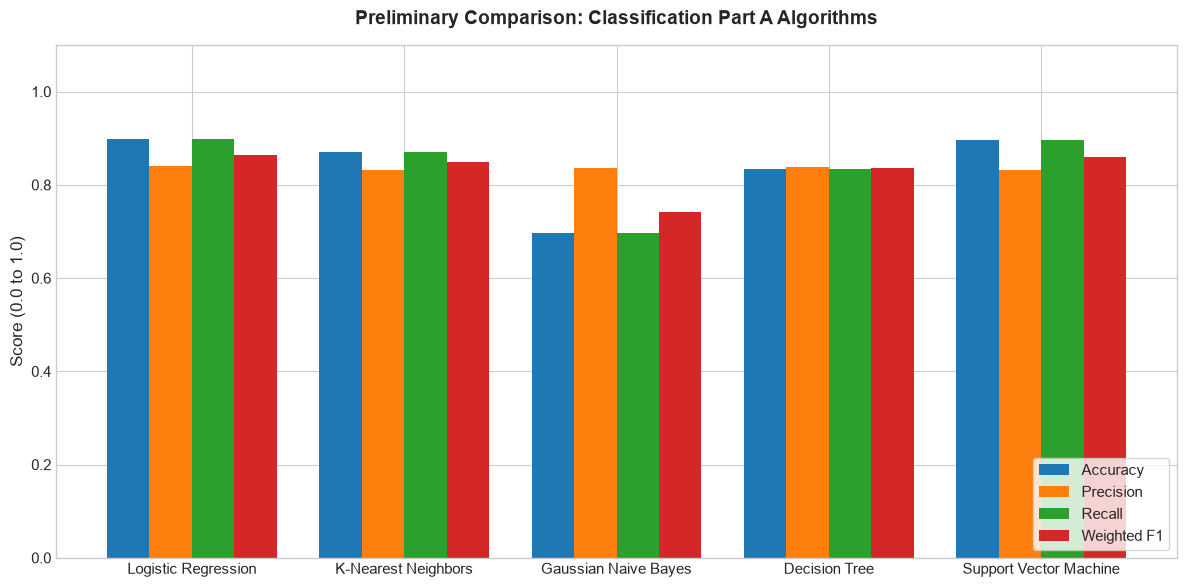

In [23]:
# Visual comparison of Part A algorithms
fig, ax = plt.subplots(figsize=(12, 6))

metrics_to_plot = ["Accuracy", "Precision", "Recall", "Weighted F1"]
x = np.arange(len(df_part_a))
width = 0.2

for idx, metric in enumerate(metrics_to_plot):
    ax.bar(x + idx * width, df_part_a[metric], width, label=metric)

ax.set_title("Preliminary Comparison: Classification Part A Algorithms", fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel("Score (0.0 to 1.0)", fontsize=12)
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(df_part_a["Model"], fontsize=11)
ax.set_ylim(0, 1.1)
ax.legend(loc="lower right", frameon=True)
plt.tight_layout()
plt.show()

### Analytical Summary of Part A Findings:
1. **Top Performers**: **Logistic Regression** and **Support Vector Machine (SVM)** achieved top accuracy (~89.7%–89.9%) and weighted F1 scores (~85.9%–86.4%) with high multiclass ROC-AUC scores (>0.98), demonstrating the effectiveness of standardized flow representations.
2. **K-Nearest Neighbors**: KNN demonstrated robust performance (Accuracy: ~87.2%, F1: ~84.8%) with rapid inference.
3. **Decision Tree**: Decision Tree achieved ~83.3% accuracy, offering interpretable orthogonal decision boundaries.
4. **Gaussian Naive Bayes**: GNB achieved ~69.7% accuracy, reflecting the impact of the feature independence assumption on correlated network metrics, while still maintaining high ROC-AUC (~0.978).

## 20. Classification Part B — To Be Completed

The remaining five algorithms for the complete 10-model classification track will be implemented in Part B:

6. **Random Forest Classifier** (Bagged ensemble of randomized decision trees)
7. **AdaBoost Classifier** (Adaptive boosting focusing on misclassified flows)
8. **Gradient Boosting Classifier** (Stage-wise gradient loss minimization)
9. **Bagging Classifier** (Bootstrap aggregating on base estimators)
10. **Multi-Layer Perceptron (MLP) Classifier** (Feedforward artificial neural network)

### Handoff Instructions for Part B:
- **Preserved Split**: Part B models must reuse the exact training and testing sets: `X_train`, `X_test`, `y_train`, `y_test`.
- **Preserved Preprocessing**: Use `X_train_scaled` and `X_test_scaled` for neural and distance/gradient models; use `X_train` and `X_test` for tree ensembles.
- **Shared Evaluation**: Call `evaluate_classifier(name, model, ...)` to seamlessly append results to the existing `results = []` list.

## 21. Final 10-Model Comparison — To Be Completed

*(Placeholder)*

The final 10-model comparative analysis, leaderboard visualization, and production model selection will be compiled here after Part B implementation is complete.